In [32]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler


# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [33]:
print(device)

cuda


In [34]:
import gc

gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_allocated() / 1024**2, "MB")

2316.296875 MB


In [35]:
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.OxfordIIITPet(
    root='./data',
    split='trainval',   # train + validation вместе
    download=True,
    transform=transform
)

test_dataset = datasets.OxfordIIITPet(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_ds, val_ds = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # фиксируем split
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
valid_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
train_dataset = datasets.CIFAR10(root=r'C:\MLbrat\andre\MoneyApp\datasets\data_cifar10', train= True, download=True, transform=transform)

test_dataset = datasets.CIFAR10(root=r'C:\MLbrat\andre\MoneyApp\datasets\data_cifar10', train= False, download=True, transform=transform)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=48, shuffle=False)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=48, shuffle=True)

In [37]:
class my_VGG(nn.Module):
    def __init__(self, num_classes=10):
        super(my_VGG, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU())
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU())
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer5 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU())
        self.layer6 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU())
        self.layer7 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer8 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer9 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer10 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer11 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer12 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer13 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(7*7*512, 4096),
            nn.ReLU())
        self.fc1 = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU())
        self.fc2= nn.Sequential(
            nn.Linear(4096, num_classes))
        
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.layer5(out)
        out = self.layer6(out)
        out = self.layer7(out)
        out = self.layer8(out)
        out = self.layer9(out)
        out = self.layer10(out)
        out = self.layer11(out)
        out = self.layer12(out)
        out = self.layer13(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

In [38]:
num_classes = 37  
batch_size = 16
learning_rate = 0.005

model = my_VGG(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate, weight_decay=0.005, momentum=0.9)

total_step = len(train_loader)

In [39]:
# один раз
fixed_images, fixed_labels = next(iter(train_loader))
fixed_image = fixed_images[0].unsqueeze(0).to(device)
fixed_label = fixed_labels[0].item()

In [40]:
print(model)

my_VGG(
  (layer1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer4): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode

In [41]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

for name, layer in model.named_modules():
    if isinstance(layer, torch.nn.Conv2d):
        layer.register_forward_hook(get_activation(name))

In [42]:
print(activations.keys())

dict_keys([])


In [43]:
import matplotlib.pyplot as plt

def show_feature_maps(feature_map, num_maps=6):
    feature_map = feature_map.squeeze(0)  # [C, H, W]

    plt.figure(figsize=(15, 5))
    for i in range(num_maps):
        plt.subplot(1, num_maps, i+1)
        plt.imshow(feature_map[i].cpu(), cmap='viridis')
        plt.axis('off')
    plt.show()

In [44]:
print(sum(p.numel() for p in model.parameters()) / 1e6, "M params")

134.420581 M params


In [45]:
model.eval()

with torch.no_grad():
    _ = model(fixed_image)   # ← ЭТО ОБЯЗАТЕЛЬНО

print(activations.keys())    # ← проверка

show_feature_maps(activations['layer1.0'])

dict_keys(['layer1.0', 'layer2.0', 'layer3.0', 'layer4.0', 'layer5.0', 'layer6.0', 'layer7.0', 'layer8.0', 'layer9.0', 'layer10.0', 'layer11.0', 'layer12.0', 'layer13.0'])


KeyboardInterrupt: 

In [ ]:
#from torch.cuda.amp import autocast, GradScaler
from torch.amp import GradScaler
total_step = len(train_loader)
num_epochs = 5

scaler = GradScaler()

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0
    

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.autocast(device_type="cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_acc = 100 * correct / total

    print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
                   .format(epoch+1, num_epochs, 1, total_step, loss.item()))
    print(f"Acc: {train_acc:.2f}%")
    
    model.eval()
    with torch.no_grad():
        _ = model(fixed_image)

    show_feature_maps(activations['layer1.0'])
    show_feature_maps(activations['layer5.0'])
    show_feature_maps(activations['layer10.0'])
    



NameError: name 'total' is not defined

Текущая папка проекта: c:\MLbrat\andre\MoneyApp\itsc\vgg
Успех! Загружаю файл: data\oxford-iiit-pet\images\Abyssinian_1.jpg
Прогон завершен успешно!


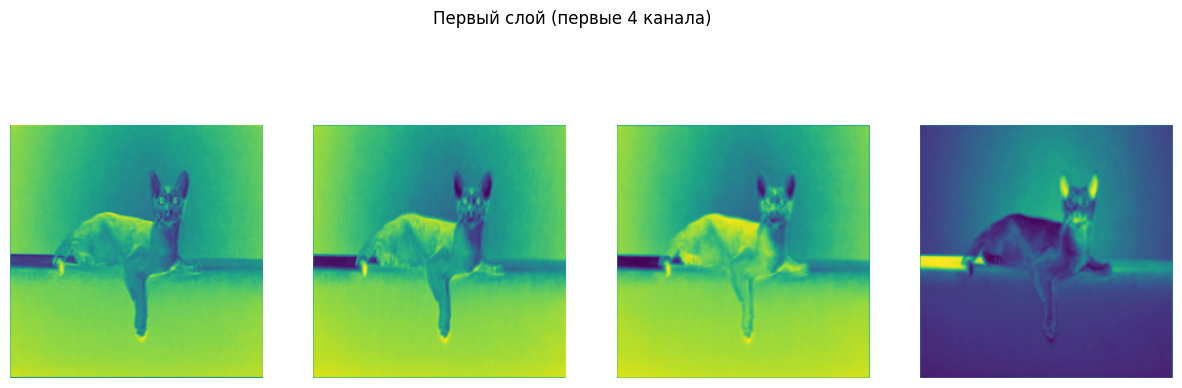

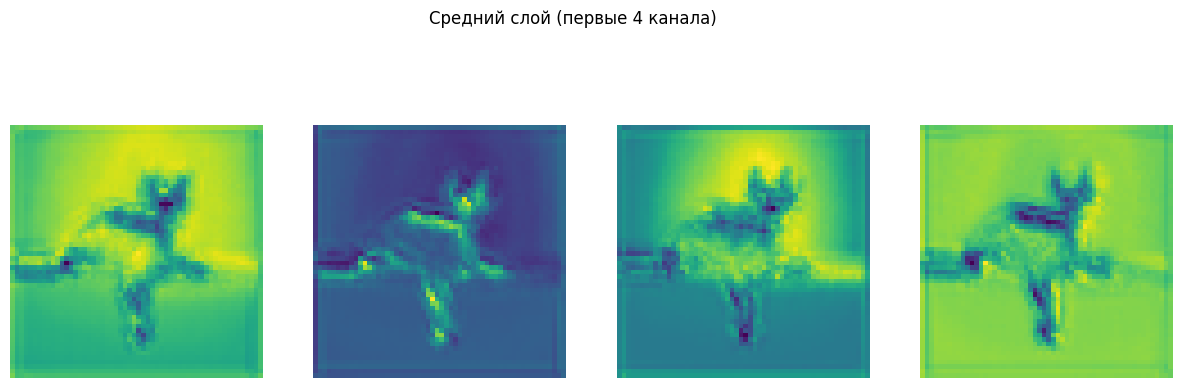

In [ ]:
import os
import torch
from PIL import Image
from torchvision import transforms

# 1. Проверка пути (ВАЖНО)
# Посмотрим, где мы находимся сейчас
print(f"Текущая папка проекта: {os.getcwd()}")

folder_path = r"data\oxford-iiit-pet\images"

# Проверяем, существует ли папка
if not os.path.exists(folder_path):
    raise FileNotFoundError(f"ПАПКА НЕ НАЙДЕНА! Проверьте путь: {os.path.abspath(folder_path)}")

# Ищем файлы
files = [f for f in os.listdir(folder_path) if f.lower().endswith('.jpg')]

if len(files) == 0:
    raise FileNotFoundError(f"В папке найдены файлы, но нет .jpg картинок: {folder_path}")

# Если мы здесь, значит файлы есть
img_path = os.path.join(folder_path, files[0])
print(f"Успех! Загружаю файл: {img_path}")

# 2. Подготовка тензора
img = Image.open(img_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
img_tensor = transform(img).unsqueeze(0) # ТЕПЕРЬ он точно определен
img_tensor = img_tensor.to(device)

# 3. Hook и Модель
activations = {}
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Регистрируем хуки (используем ваши имена слоев layer1, layer7)
model.layer1[0].register_forward_hook(get_activation('first_layer'))
model.layer7[0].register_forward_hook(get_activation('middle_layer'))

model.eval()

# 4. Прогон (теперь img_tensor гарантированно существует)
with torch.no_grad():
    output = model(img_tensor)

print("Прогон завершен успешно!")

# 5. Визуализация
def plot_activations(act, title):
    act = act[0] # [C, H, W]
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))
    fig.suptitle(title)
    for i in range(4):
        axes[i].imshow(act[i].cpu().numpy(), cmap='viridis')
        axes[i].axis('off')
    plt.show()

if 'first_layer' in activations:
    plot_activations(activations['first_layer'], "Первый слой (первые 4 канала)")
if 'middle_layer' in activations:
    plot_activations(activations['middle_layer'], "Средний слой (первые 4 канала)")

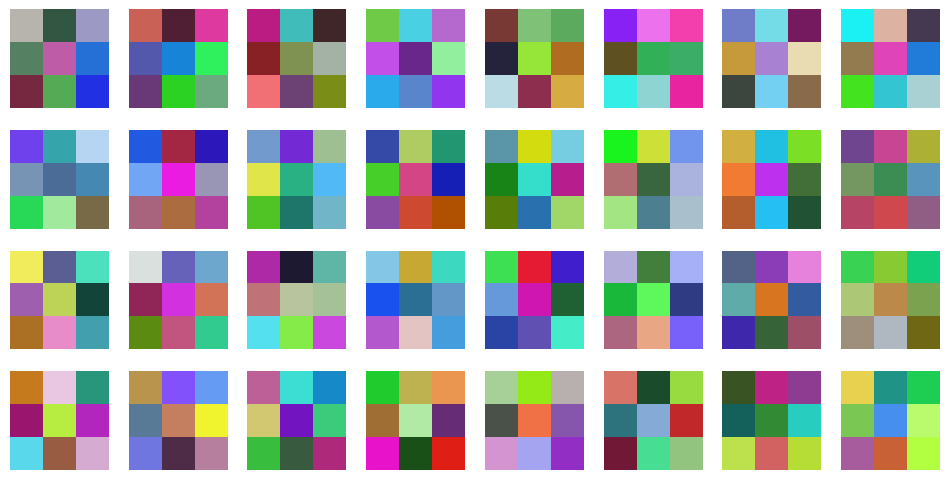

In [ ]:
kernels = model.layer1[0].weight.detach().cpu()

# Нормализуем веса для отрисовки (0-1)
kernels_min, kernels_max = kernels.min(), kernels.max()
kernels = (kernels - kernels_min) / (kernels_max - kernels_min)

fig, axarr = plt.subplots(4, 8, figsize=(12, 6)) # Для 32 фильтров
for i in range(32):
    # У фильтра 3 канала (RGB), их можно отобразить как картинку
    axarr[i//8, i%8].imshow(kernels[i].permute(1, 2, 0)) 
    axarr[i//8, i%8].axis('off')

In [ ]:
images, labels = next(iter(test_loader))

# Берем первую картинку из батча
input_tensor = images[0].unsqueeze(0) 
# или просто весь батч, если хотите прогнать сразу много картинок
# input_tensor = images 

print(input_tensor.shape)

torch.Size([1, 3, 224, 224])


In [ ]:
import torch
import numpy as np
from PIL import Image

# 1. Определяем устройство, на котором находится модель
device = next(model.parameters()).device

# 2. Загружаем и подготавливаем изображение
img_pil = Image.open(r"data\oxford-iiit-pet\images\Abyssinian_1.jpg").convert('RGB').resize((224, 224))

# Переводим в массив и делим на 255
rgb_img = np.float32(img_pil) / 255.0

# ВАЖНО: Превращаем numpy-массив в тензор PyTorch
# Меняем оси с (H, W, C) на (C, H, W) и добавляем Batch-размер (1, C, H, W)
input_tensor = torch.from_numpy(rgb_img).permute(2, 0, 1).unsqueeze(0)

# 3. ПЕРЕНОСИМ ТЕНЗОР НА ТО ЖЕ УСТРОЙСТВО, ЧТО И МОДЕЛЬ
input_tensor = input_tensor.to(device)

# 4. Прогон
model.eval()
with torch.no_grad():
    output = model(input_tensor) # Теперь ошибки не будет!
    
    probabilities = torch.softmax(output, dim=1)
    predicted_class_idx = torch.argmax(probabilities, dim=1).item()

print(f"Модель считает, что это класс номер: {predicted_class_idx}")

# 5. Подготовка для визуализации (обратно на CPU и в Numpy)
transformed_img = input_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()

Модель считает, что это класс номер: 23


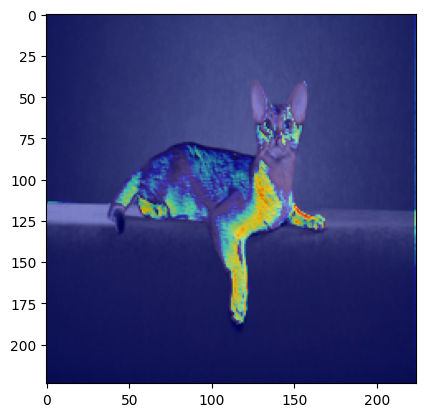

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Выбираем целевой слой (последний сверточный слой в VGG - это обычно features[-1])
target_layers = [model.layer1[-1]]

cam = GradCAM(model=model, target_layers=target_layers)

# Выбираем класс, который хотим визуализировать (например, 281 - Tabby Cat)
targets = [ClassifierOutputTarget(35)]

# Генерируем маску
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

# Накладываем на оригинальное изображение
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
plt.imshow(visualization)

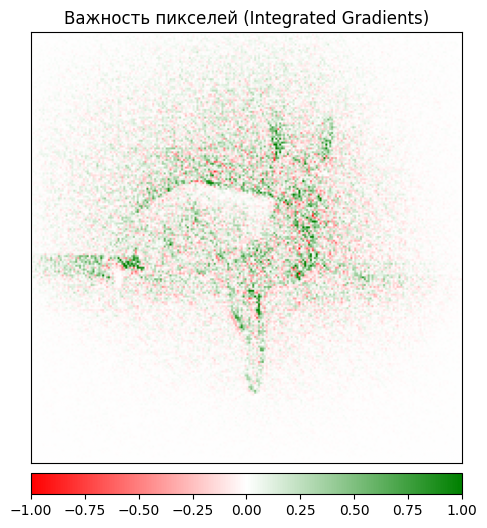

In [ ]:
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz
import numpy as np

# 1. Создаем объект IntegratedGradients
ig = IntegratedGradients(model)

# 2. Получаем атрибуцию (важность пикселей)
# Важно: для Captum часто нужно включить градиенты, даже если мы в eval моде
attributions, delta = ig.attribute(input_tensor, target=predicted_class_idx, return_convergence_delta=True)

# 3. Подготавливаем данные для визуализации
# Атрибуции: переводим в numpy и меняем оси с [C, H, W] на [H, W, C]
attr_np = np.transpose(attributions.squeeze().cpu().detach().numpy(), (1, 2, 0))

# Оригинальное фото: берем наш rgb_img, который уже в формате numpy [H, W, C]
img_np = rgb_img 

# 4. Визуализируем
_ = viz.visualize_image_attr(
    attr_np,
    img_np,
    method='heat_map',
    sign='all',
    show_colorbar=True,
    title="Важность пикселей (Integrated Gradients)"
)

In [ ]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy: {accuracy:.2f}%')